In [1]:
%load_ext watermark


In [2]:
import os
import random

import alifedata_phyloinformatics_convert as apc
from hstrat import _auxiliary_lib as hstrat_aux
from matplotlib import pyplot as plt
import numpy as np
import iplotx as ipx
import pandas as pd
from teeplot import teeplot as tp

hstrat_aux.seed_random(5)


/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-10-26T11:31:09.059241+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1036-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

iplotx                            : 1.2.1
teeplot                           : 1.4.2
hstrat                            : 1.20.19
matplotlib                        : 3.10.0
pandas                            : 2.2.3
numpy                             : 2.1.2
alifedata_phyloinformatics_convert: 0.19.3

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2025-10-20-mls-strong-fossils__wse-async-ga")
teeplot_subdir


'2025-10-20-mls-strong-fossils__wse-async-ga'

## Prep Data


In [5]:
df = pd.read_parquet("https://osf.io/download/u4kzw/")


In [6]:
df = hstrat_aux.alifestd_downsample_tips_clade_asexual(df, 512, seed=10)


In [7]:
df = hstrat_aux.alifestd_to_working_format(df)
df["origin_time"] = df["hstrat_rank_from_t0"]
df = hstrat_aux.alifestd_mark_origin_time_delta_asexual(df)
df.fillna({"origin_time": 0}, inplace=True)
df


,id,dstream_data_id,ancestor_id,is_extant,layer,position,genomeFlavor,globalSeed,nCol,nRow,...,fitness,tile,row,col,origin_time,hstrat_rank_from_t0,is_leaf,num_leaves,ancestor_origin_time,origin_time_delta
0,0,NaN,0,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,False,1186649,NaN,NaN
1,1,9.223372e+18,0,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,62.0,62.0,False,1186649,NaN,NaN
2,2,9.223372e+18,1,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,126.0,126.0,False,920469,62.0,64.0
3,3,9.223372e+18,2,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,254.0,254.0,False,464590,126.0,128.0
4,4,9.223372e+18,3,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,318.0,318.0,False,285823,254.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,1007,9.223372e+18,995,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,112415.0,112415.0,False,2,112383.0,32.0
1008,1008,5.303580e+05,1007,False,9.0,413383.0,genome_mls_2025_08_15,1.0,755.0,1170.0,...,NaN,NaN,NaN,NaN,112655.0,112655.0,True,1,112415.0,240.0
1009,1009,3.909133e+06,994,False,9.0,413381.0,genome_mls_2025_08_15,1.0,755.0,1170.0,...,NaN,NaN,NaN,NaN,112655.0,112655.0,True,1,112255.0,400.0
1010,1010,1.247427e+06,1007,False,9.0,413378.0,genome_mls_2025_08_15,1.0,755.0,1170.0,...,NaN,NaN,NaN,NaN,112667.0,112667.0,True,1,112415.0,252.0


In [8]:
clip = 100_000
df["extant"] = df["origin_time"] > clip
dfx = hstrat_aux.alifestd_prune_extinct_lineages_asexual(df)
dfx = hstrat_aux.alifestd_collapse_unifurcations(dfx)

tree = apc.alife_dataframe_to_dendropy_tree(
    hstrat_aux.alifestd_try_add_ancestor_list_col(
        dfx,
    ),
    setattrs=[
        "focal_trait_count",
        *[f"trait_num{i}" for i in range(64)],
    ],
    # setup_edge_lengths=True,
)


/usr/local/lib/python3.10/dist-packages/hstrat/_auxiliary_lib/_alifestd_collapse_unifurcations.py:113: UserWarning: alifestd_collapse_unifurcations does not update branch length columns. Use `origin_time` to recalculate branch lengths for collapsed phylogeny.
  warnings.warn(


In [9]:
with hstrat_aux.RngStateContext(6):
    tree.ladderize()
    tree.reorder(key=lambda *args: max(random.random(), 0.89))


## Example Plot


teeplots/edge-color=darkgray+layout=radial+viz=tree+ext=.pdf
teeplots/edge-color=darkgray+layout=radial+viz=tree+ext=.png


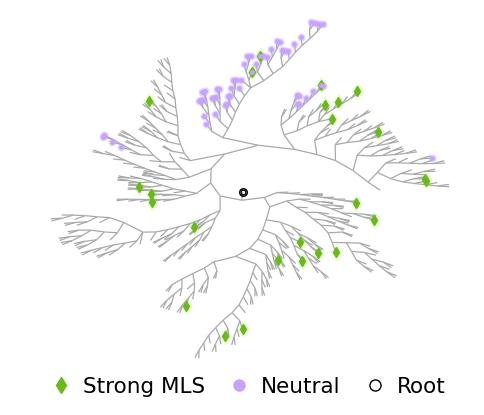

In [10]:
with tp.teed(
    ipx.plotting.tree,
    tree,
    aspect=0.7,
    edge_color="darkgray",
    edge_linewidth=0.9,
    ladderize=True,
    layout="radial",
    layout_angular=True,
    layout_start=0.25,
    margins=0,
) as teed:
    ax = teed.axes
    plt.gcf().set_size_inches(6, 6)

    for n, (x, y) in teed.get_layout().T.items():
        x_, y_ = x * np.cos(y), x * np.sin(y)
        if n.focal_trait_count == 1.0:
            plt.plot(x_, y_, "d", markersize=8, color="#E2FFC4", alpha=0.8, zorder=0)
            plt.plot(x_, y_, "d", markersize=5, color="#6AB81C", alpha=1, zorder=2)
        if n.trait_num17 == 1.0:
            plt.plot(x_, y_, "o", markersize=5, color="#C5A3FF", alpha=0.3, zorder=1)
            plt.plot(x_, y_, "o", markersize=2.5, color="#C5A3FF", alpha=1.0, zorder=3)
        if n is tree.seed_node:
            plt.plot(x_, y_, "o", markersize=3.5, color="black", alpha=1, fillstyle="none")
            plt.plot(x_, y_, "o", markersize=5.5, color="black", alpha=1, fillstyle="none")

    plt.gca().margins(x=-0.1,y=-0.05)

    h1, = plt.plot([], [], "d", markersize=8, color="#6AB81C", label="Strong MLS")
    h2, = plt.plot([], [], "o", markersize=8, color="#C5A3FF", label="Neutral")
    h3, = plt.plot([], [], "o", markersize=8, color="black", fillstyle="none", label="Root")

    plt.legend(
        handles=[h1, h2, h3],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.05),
        frameon=False,
        ncol=3,
        fontsize=15.5,
        columnspacing=0.6,
        handletextpad=0.0,
    )
